In [14]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D
from astropy.io import fits
from astropy.table import Table

In [40]:
candels_cat_file = '../catalog/gds.fits'
other_candels_cat_file = '../catalog/hlsp_candels_hst_wfc3_goodss-tot-multiband_f160w_v1_cat.fits'

jwst_files = glob.glob("../data/JWST_JADES/*")
nisp_files = glob.glob("../data/NISP_HUDF/*")

In [ ]:
def match_catalog(file_name, gal_coords, hdu=0, url=None, dbx=None):
    if url is None: # get images locally
        with fits.open(file_name) as hdul:
            image_header = hdul[hdu].header
            image_data = hdul[hdu].data
    else: # Get FITS file from dropbox
        image_header, image_data = get_fits_file(url, file_name, dbx=dbx)
    
    wcs = WCS(image_header)
    
    return np.where(gal_coords.contained_by(wcs))[0]

In [38]:
tbl = Table.read(candels_cat_file).to_pandas()
tbl['ACS_F814W_MAG'] = 23.9-2.5*np.log10(tbl.ACS_F814W_FLUX)
tbl = tbl[
        (tbl.z_best > 0.01) & (tbl.z_best < 3.0)
        & (tbl.ACS_F814W_MAG < 25)
        & (tbl.FLUX_RADIUS_2_F814W < 24)
        & (tbl.CLASS_STAR < 0.05)
]

/home/eaev/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [57]:
gal_coords = SkyCoord(tbl.RAdeg, tbl.DECdeg, unit='deg')

In [60]:
with fits.open(jwst_files[0]) as hdul:
    print(hdul.info())
    jwst_hdr = hdul[1].header
    jwst_data = hdul[1].data
wcs = WCS(jwst_hdr)
gal_coords = gal_coords[np.where(gal_coords.contained_by(wcs))[0]]

Filename: ../data/JWST_JADES/hlsp_jades_jwst_nircam_goods-s-deep_f115w_v2.0_drz.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     442   ()      
  1  SCI           1 ImageHDU        83   (25000, 27700)   float32   
  2  ERR           1 ImageHDU        83   (25000, 27700)   float32   
  3  EXP           1 ImageHDU        83   (25000, 27700)   float32   
  4  WHT           1 ImageHDU        83   (25000, 27700)   float32   
None


Set DATE-AVG to '2022-10-08T02:26:24.819' from MJD-AVG.
Set DATE-END to '2022-10-09T02:34:11.369' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    22.090597 from OBSGEO-[XYZ].
Set OBSGEO-H to 1234812278.786 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


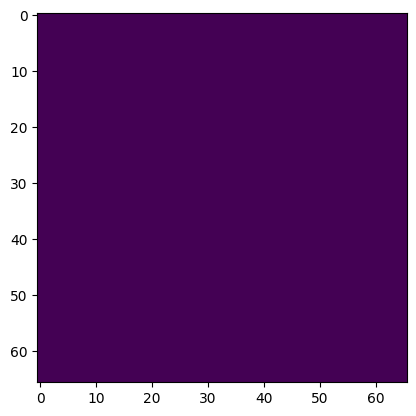

In [61]:
clip = Cutout2D(jwst_data, gal_coords[100], size=66, wcs=wcs)
plt.imshow(clip.data)

In [27]:
tbl_other = Table.read(other_candels_cat_file).to_pandas()